# Fine-tuning IndoBERT untuk Klasifikasi Hoax

## Strategi

**Perbedaan dari Feature Extraction (notebook sebelumnya):**

| Aspek | Feature Extraction | Fine-tuning |
|---|---|---|
| Model IndoBERT | Frozen (tidak berubah) | **Diupdate selama training** |
| Classifier | LinearSVC (terpisah) | **Classification head terintegrasi** |
| Parameter yang diupdate | Hanya ~100k (SVM) | **124M (BERT + head)** |
| Waktu training | Cepat (menit) | **Lebih lambat (puluhan menit)** |
| Hasil akurasi | Baseline ~88% | **Potensi 90-95%** |

**Strategi penghematan resource:**
- Freeze bottom 10 layers (embedding + blocks 0-9)
- Fine-tune seluruh transformer blocks + classification head
- Learning rate rendah (2e-5) untuk perlahan update weights
- Early stopping untuk mencegah overfitting

---

**Files yang dibutuhkan:**
```
Data_latih.csv
Data_uji.csv
detik.csv
```

## 1. Imports & Setup

In [67]:
# !pip install transformers torch scikit-learn pandas numpy seaborn matplotlib PySastrawi datasets

In [68]:
import re
import html
import json
import time
from pathlib import Path
from functools import lru_cache

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    AdamW, get_linear_schedule_with_warmup,
)

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
)
from sklearn.model_selection import StratifiedShuffleSplit

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✓ Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print('✓ Imports OK')

✓ Device: cuda
  GPU : NVIDIA GeForce RTX 3060 Ti
  VRAM: 8.6 GB
✓ Imports OK


## 2. Konfigurasi

In [69]:
ROOT = Path.cwd()
if not (ROOT / 'Data_latih.csv').exists():
    for candidate in [ROOT.parent, *ROOT.parents]:
        if (candidate / 'Data_latih.csv').exists():
            ROOT = candidate
            break

ARTIFACT_DIR = ROOT / 'artifacts_finetuning'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# ─── Model ───────────────────────────────────────────────────────────────────
MODEL_NAME = 'indobenchmark/indobert-base-p1'
NUM_LABELS = 2

# ─── Training hyperparameter ─────────────────────────────────────────────────
BATCH_SIZE       = 16      # Turunkan ke 8 jika OOM
LEARNING_RATE    = 2e-5    # Rendah untuk fine-tune (default BERT: 2-5e-5)
EPOCHS           = 10       # Dengan early stopping, biasanya henti di epoch 2-3
MAX_LEN          = 256     # Maksimum token per teks
WARMUP_RATIO     = 0.1     # 10% dari total steps untuk warmup
RANDOM_SEED      = 42

# ─── Strategi fine-tuning ────────────────────────────────────────────────────
# Layer strategy: freeze bottom layers, only train top layers
# 'base' punya 12 encoder layers (0-11):
#   - Freeze layers 0-9 (embeddings learned)
#   - Train layers 10-11 + head (task-specific)
FREEZE_UNTIL_LAYER = 10   # Freeze layer 0 s/d 9, train layer 10-11

# ─── Early stopping ──────────────────────────────────────────────────────────
PATIENCE = 2               # Hentikan jika val_loss tidak improve 2 epochs
VAL_SPLIT = 0.15          # 15% data untuk validation (dari training set)

# ─── Augmentasi ──────────────────────────────────────────────────────────────
USE_AUGMENTATION = True    # Tambah data dari detik.csv
MAX_AUGMENT = None         # None = seimbang kelas, atau set angka

LABEL_MAP = {0: 'Tidak Hoax', 1: 'Hoax'}

print(f'✓ Project root : {ROOT}')
print(f'✓ Model        : {MODEL_NAME}')
print(f'✓ Max len      : {MAX_LEN} tokens')
print(f'✓ Batch size   : {BATCH_SIZE}')
print(f'✓ Learning rate: {LEARNING_RATE}')
print(f'✓ Epochs       : {EPOCHS} (dengan early stopping)')
print(f'✓ Freeze until : layer {FREEZE_UNTIL_LAYER} (train layer {FREEZE_UNTIL_LAYER}-11 + head)')
print(f'✓ Augmentasi   : {USE_AUGMENTATION}')

✓ Project root : d:\Export Tugas\AI\ProjectAkhir\notebooks
✓ Model        : indobenchmark/indobert-base-p1
✓ Max len      : 256 tokens
✓ Batch size   : 16
✓ Learning rate: 2e-05
✓ Epochs       : 10 (dengan early stopping)
✓ Freeze until : layer 10 (train layer 10-11 + head)
✓ Augmentasi   : True


## 3. Preprocessing

In [70]:
_URL_RE        = re.compile(r'https?://\S+|www\.\S+', re.IGNORECASE)
_HTML_TAG_RE   = re.compile(r'<[^>]+')
_NON_LETTER_RE = re.compile(r'[^a-zA-Z\s]')
_MULTI_SPACE   = re.compile(r'\s+')

@lru_cache(maxsize=1)
def get_stopwords() -> set:
    return set(StopWordRemoverFactory().get_stop_words())

def normalize_text(text: object) -> str:
    """Clean text — lowercase, remove URL/HTML/non-letters."""
    if pd.isna(text):
        return ''
    value = html.unescape(str(text)).lower()
    value = _URL_RE.sub(' ', value)
    value = _HTML_TAG_RE.sub(' ', value)
    value = _NON_LETTER_RE.sub(' ', value)
    return _MULTI_SPACE.sub(' ', value).strip()

def combine_fields(df: pd.DataFrame) -> pd.Series:
    title = df.get('judul',  pd.Series([''] * len(df), index=df.index)).fillna('').astype(str)
    body  = df.get('narasi', pd.Series([''] * len(df), index=df.index)).fillna('').astype(str)
    return title.str.cat(body, sep=' ')

print('✓ Preprocessing functions loaded')

✓ Preprocessing functions loaded


## 4. Load & Augmentasi Data

In [71]:
train_df = pd.read_csv(ROOT / 'Data_latih.csv')
test_df  = pd.read_csv(ROOT / 'Data_uji.csv')
detik_df = pd.read_csv(ROOT / 'detik.csv')

print('=== Dataset Asli ===')
print(f'Train: {len(train_df):,} | {dict(train_df["label"].value_counts().sort_index())}')
print(f'Test : {len(test_df):,} | (tanpa label)')
print(f'Detik: {len(detik_df):,} | label 0 semua')

=== Dataset Asli ===
Train: 4,231 | {0: np.int64(766), 1: np.int64(3465)}
Test : 470 | (tanpa label)
Detik: 3,576 | label 0 semua


In [72]:
def build_augmented_data(train_df, detik_df, max_augment=None, random_state=RANDOM_SEED):
    label_counts = train_df['label'].value_counts().sort_index()
    n_label0 = int(label_counts.get(0, 0))
    n_label1 = int(label_counts.get(1, 0))
    needed = max(n_label1 - n_label0, 0)

    if needed == 0:
        return train_df.copy()

    print(f'Augmentasi: perlu tambah {needed:,} sampel label 0')

    candidates = detik_df.copy()
    if 'clean_text' in candidates.columns:
        text_col = candidates['clean_text'].fillna('').astype(str)
    else:
        text_col = combine_fields(candidates).map(normalize_text)

    candidates['_text'] = text_col
    candidates['label'] = 0
    candidates = candidates[candidates['_text'].str.split().str.len() >= 8]

    train_texts = set(combine_fields(train_df).map(normalize_text).str.strip())
    candidates = candidates[~candidates['_text'].str.strip().isin(train_texts)]
    candidates = candidates.drop_duplicates(subset=['_text'])

    n_take = needed if max_augment is None else min(needed, max_augment)
    n_take = min(n_take, len(candidates))
    print(f'  Diambil: {n_take:,} dari {len(candidates):,} kandidat')

    sampled = candidates.sample(n=n_take, random_state=random_state)
    aug_rows = pd.DataFrame({
        'judul' : sampled.get('judul',  pd.Series([''] * len(sampled))).fillna('').values,
        'narasi': sampled.get('narasi', pd.Series([''] * len(sampled))).fillna('').values,
        'label' : 0,
    })

    combined = pd.concat([train_df, aug_rows], ignore_index=True)
    combined = combined.sample(frac=1, random_state=random_state).reset_index(drop=True)

    final_counts = combined['label'].value_counts().sort_index()
    print(f'  Hasil: {dict(final_counts)}')
    return combined

if USE_AUGMENTATION:
    train_data = build_augmented_data(train_df, detik_df, max_augment=MAX_AUGMENT)
else:
    train_data = train_df.copy()
    print('Augmentasi dilewati')

Augmentasi: perlu tambah 2,699 sampel label 0
  Diambil: 2,699 dari 3,576 kandidat
  Hasil: {0: np.int64(3465), 1: np.int64(3465)}


In [73]:
# Siapkan teks (gunakan normalize saja, jangan hapus stopwords — BERT butuh konteks penuh)
texts_train = combine_fields(train_data).map(normalize_text).tolist()
labels_train = train_data['label'].values

texts_test = combine_fields(test_df).map(normalize_text).tolist()

print(f'✓ Train: {len(texts_train):,} teks')
print(f'✓ Test : {len(texts_test):,} teks')

✓ Train: 6,930 teks
✓ Test : 470 teks


## 5. Tokenisasi & Dataset Preparation

In [74]:
print(f'Memuat tokenizer: {MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('✓ Tokenizer loaded')

def tokenize_batch(texts, tokenizer, max_len=MAX_LEN):
    """Tokenize batch of texts."""
    encoded = tokenizer(
        texts,
        padding='max_length',
        truncation=True,
        max_length=max_len,
        return_tensors='pt',
    )
    return encoded['input_ids'], encoded['attention_mask']

# Tokenisasi training data
print(f'Tokenisasi {len(texts_train):,} teks train...')
input_ids_train, attention_mask_train = tokenize_batch(texts_train, tokenizer)
labels_train_tensor = torch.tensor(labels_train, dtype=torch.long)

print(f'  Input IDs shape: {input_ids_train.shape}')
print(f'  Attention mask : {attention_mask_train.shape}')
print(f'  Labels shape   : {labels_train_tensor.shape}')

# Tokenisasi test data
print(f'Tokenisasi {len(texts_test):,} teks test...')
input_ids_test, attention_mask_test = tokenize_batch(texts_test, tokenizer)

# Buat PyTorch datasets
train_dataset = TensorDataset(input_ids_train, attention_mask_train, labels_train_tensor)

print(f'✓ Train dataset: {len(train_dataset):,} sampel')

Memuat tokenizer: indobenchmark/indobert-base-p1


d:\Export Tugas\AI\ProjectAkhir\.venv-1\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


✓ Tokenizer loaded
Tokenisasi 6,930 teks train...
  Input IDs shape: torch.Size([6930, 256])
  Attention mask : torch.Size([6930, 256])
  Labels shape   : torch.Size([6930])
Tokenisasi 470 teks test...
✓ Train dataset: 6,930 sampel


## 6. Split Train-Validation

In [75]:
# Stratified split — jaga distribusi kelas
splitter = StratifiedShuffleSplit(n_splits=1, test_size=VAL_SPLIT, random_state=RANDOM_SEED)
train_idx, val_idx = next(splitter.split(labels_train, labels_train))

from torch.utils.data import Subset
train_subset = Subset(train_dataset, train_idx)
val_subset   = Subset(train_dataset, val_idx)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_subset, batch_size=BATCH_SIZE)

print(f'Train set: {len(train_subset):,} ({len(train_subset)/len(train_dataset)*100:.1f}%)')
print(f'Val set  : {len(val_subset):,} ({len(val_subset)/len(train_dataset)*100:.1f}%)')
print(f'Train batches: {len(train_loader)}')
print(f'Val batches  : {len(val_loader)}')

Train set: 5,890 (85.0%)
Val set  : 1,040 (15.0%)
Train batches: 369
Val batches  : 65


## 7. Load Model & Setup Fine-tuning

In [76]:
print(f'Memuat model: {MODEL_NAME}')
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters()) / 1e6
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6

print(f'✓ Model loaded: {total_params:.1f}M total parameter')
print(f'  Awalnya, semua {trainable_params:.1f}M dapat diupdate')

Memuat model: indobenchmark/indobert-base-p1


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Model loaded: 124.4M total parameter
  Awalnya, semua 124.4M dapat diupdate


In [77]:
def freeze_layers(model, freeze_until_layer: int):
    """
    Freeze layers sesuai config. Jika freeze_until_layer=None, jalankan full fine-tune.
    """
    if freeze_until_layer is None:
        # FULL FINE-TUNING: tidak freeze apapun
        for param in model.parameters():
            param.requires_grad = True
        
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
        total = sum(p.numel() for p in model.parameters()) / 1e6
        print(f'✓ FULL FINE-TUNING: Semua {trainable:.1f}M parameter dapat diupdate')
        return trainable, total
    else:
        # SELECTIVE FINE-TUNING: freeze bottom layers
        for name, param in model.named_parameters():
            if 'embeddings' in name:
                param.requires_grad = False
            elif 'encoder.layer' in name:
                layer_num = int(name.split('encoder.layer.')[1].split('.')[0])
                if layer_num < freeze_until_layer:
                    param.requires_grad = False
        
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
        total = sum(p.numel() for p in model.parameters()) / 1e6
        return trainable, total


In [78]:
# ─── Setup optimizer & scheduler ────────────────────────────────────────────
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f'Optimizer: AdamW (lr={LEARNING_RATE})')
print(f'Scheduler: Linear warmup + decay')
print(f'  Total steps  : {total_steps:,}')
print(f'  Warmup steps: {warmup_steps:,}')

loss_fn = nn.CrossEntropyLoss()
print(f'Loss function: CrossEntropyLoss (dengan class weighting internal jika needed)')

Optimizer: AdamW (lr=2e-05)
Scheduler: Linear warmup + decay
  Total steps  : 3,690
  Warmup steps: 369
Loss function: CrossEntropyLoss (dengan class weighting internal jika needed)


d:\Export Tugas\AI\ProjectAkhir\.venv-1\Lib\site-packages\transformers\optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


## 8. Training Loop

In [79]:
def evaluate(model, val_loader, loss_fn, device):
    """Evaluasi model pada validation set."""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids, attention_mask, labels = [b.to(device) for b in batch]

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )
            logits = outputs.logits
            loss = loss_fn(logits, labels)

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(val_loader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, accuracy, f1, all_preds, all_labels

print('✓ Evaluasi function OK')

✓ Evaluasi function OK


In [80]:
# ─── Early stopping setup ────────────────────────────────────────────────────
best_val_loss = float('inf')
patience_counter = 0
best_model_path = ARTIFACT_DIR / 'best_model.pt'

training_history = {
    'epoch': [],
    'train_loss': [],
    'val_loss': [],
    'val_accuracy': [],
    'val_f1': [],
}

print('Mulai training...')
print('=' * 70)

Mulai training...


In [81]:
for epoch in range(EPOCHS):
    # ─── Training phase ─────────────────────────────────────────────────────
    model.train()
    total_train_loss = 0

    for step, batch in enumerate(train_loader):
        input_ids, attention_mask, labels = [b.to(DEVICE) for b in batch]

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        logits = outputs.logits
        loss = loss_fn(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_train_loss += loss.item()

        if (step + 1) % max(1, len(train_loader) // 3) == 0:
            print(f'  Epoch {epoch+1}/{EPOCHS} | Step {step+1}/{len(train_loader)} | Loss: {loss.item():.4f}')

    avg_train_loss = total_train_loss / len(train_loader)

    # ─── Validation phase ───────────────────────────────────────────────────
    val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, loss_fn, DEVICE)

    print(f'Epoch {epoch+1} SELESAI:')
    print(f'  Train Loss: {avg_train_loss:.4f}')
    print(f'  Val Loss  : {val_loss:.4f}')
    print(f'  Val Acc   : {val_acc:.4f}')
    print(f'  Val F1    : {val_f1:.4f}')

    training_history['epoch'].append(epoch + 1)
    training_history['train_loss'].append(avg_train_loss)
    training_history['val_loss'].append(val_loss)
    training_history['val_accuracy'].append(val_acc)
    training_history['val_f1'].append(val_f1)

    # ─── Early stopping ─────────────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f'  ✓ Best model saved (val_loss: {val_loss:.4f})')
    else:
        patience_counter += 1
        print(f'  Patience: {patience_counter}/{PATIENCE}')
        if patience_counter >= PATIENCE:
            print(f'\n✓ Early stopping at epoch {epoch+1} (val_loss tidak improve {PATIENCE} epochs)')
            break

    print()

# Load best model
model.load_state_dict(torch.load(best_model_path))
print(f'✓ Best model loaded dari {best_model_path.name}')

  Epoch 1/10 | Step 123/369 | Loss: 0.4795
  Epoch 1/10 | Step 246/369 | Loss: 0.3249
  Epoch 1/10 | Step 369/369 | Loss: 0.0075
Epoch 1 SELESAI:
  Train Loss: 0.3630
  Val Loss  : 0.3337
  Val Acc   : 0.8644
  Val F1    : 0.8640
  ✓ Best model saved (val_loss: 0.3337)

  Epoch 2/10 | Step 123/369 | Loss: 0.1979
  Epoch 2/10 | Step 246/369 | Loss: 0.0728
  Epoch 2/10 | Step 369/369 | Loss: 0.4816
Epoch 2 SELESAI:
  Train Loss: 0.2363
  Val Loss  : 0.2247
  Val Acc   : 0.9154
  Val F1    : 0.9152
  ✓ Best model saved (val_loss: 0.2247)

  Epoch 3/10 | Step 123/369 | Loss: 0.2527
  Epoch 3/10 | Step 246/369 | Loss: 0.0665
  Epoch 3/10 | Step 369/369 | Loss: 0.0005
Epoch 3 SELESAI:
  Train Loss: 0.1447
  Val Loss  : 0.3578
  Val Acc   : 0.9125
  Val F1    : 0.9124
  Patience: 1/2

  Epoch 4/10 | Step 123/369 | Loss: 0.0015
  Epoch 4/10 | Step 246/369 | Loss: 0.0833
  Epoch 4/10 | Step 369/369 | Loss: 0.0011
Epoch 4 SELESAI:
  Train Loss: 0.0736
  Val Loss  : 0.4480
  Val Acc   : 0.9038
  

## 9. Plot Training History

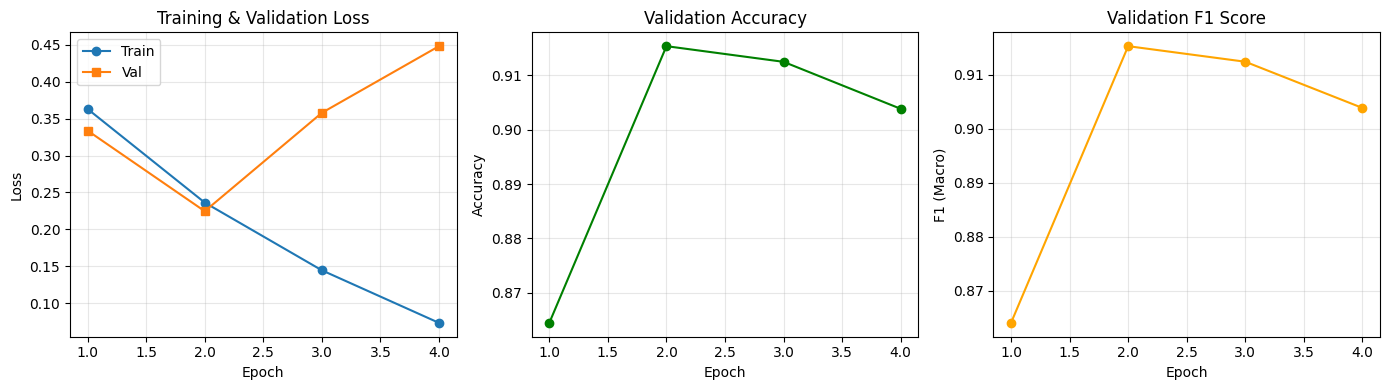

✓ Training history plot saved


In [82]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Loss
axes[0].plot(training_history['epoch'], training_history['train_loss'], marker='o', label='Train')
axes[0].plot(training_history['epoch'], training_history['val_loss'], marker='s', label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(training_history['epoch'], training_history['val_accuracy'], marker='o', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].grid(alpha=0.3)

# F1
axes[2].plot(training_history['epoch'], training_history['val_f1'], marker='o', color='orange')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 (Macro)')
axes[2].set_title('Validation F1 Score')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'training_history.png', dpi=150)
plt.show()

print(f'✓ Training history plot saved')

## 10. Evaluasi Final pada Validation Set


EVALUASI FINAL — VALIDATION SET
Loss     : 0.2247
Accuracy : 0.9154
F1 Macro : 0.9152

              precision    recall  f1-score   support

  Tidak Hoax       0.95      0.88      0.91       520
        Hoax       0.88      0.96      0.92       520

    accuracy                           0.92      1040
   macro avg       0.92      0.92      0.92      1040
weighted avg       0.92      0.92      0.92      1040



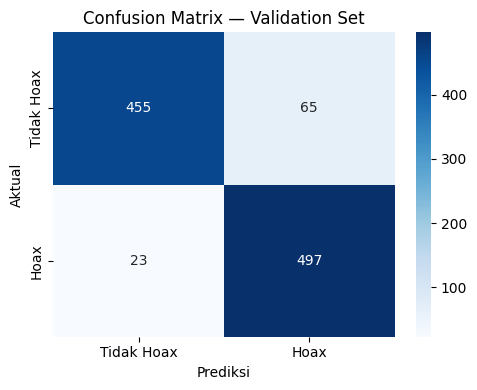

In [83]:
val_loss, val_acc, val_f1, val_preds, val_labels = evaluate(model, val_loader, loss_fn, DEVICE)

print('\n' + '='*70)
print('EVALUASI FINAL — VALIDATION SET')
print('='*70)
print(f'Loss     : {val_loss:.4f}')
print(f'Accuracy : {val_acc:.4f}')
print(f'F1 Macro : {val_f1:.4f}')
print()
print(classification_report(val_labels, val_preds, target_names=['Tidak Hoax', 'Hoax']))

cm = confusion_matrix(val_labels, val_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Tidak Hoax', 'Hoax'],
           yticklabels=['Tidak Hoax', 'Hoax'], ax=ax)
ax.set_xlabel('Prediksi')
ax.set_ylabel('Aktual')
ax.set_title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'cm_validation.png', dpi=150)
plt.show()

## 11. Prediksi Test Set

In [84]:
test_dataset = TensorDataset(input_ids_test, attention_mask_test)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

model.eval()
all_preds_test = []

with torch.no_grad():
    for i, batch in enumerate(test_loader):
        input_ids, attention_mask = [b.to(DEVICE) for b in batch]
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1).cpu().numpy()
        all_preds_test.extend(preds)
        
        if (i+1) % 10 == 0:
            print(f'Batch {i+1}/{len(test_loader)} selesai')

y_pred_test = np.array(all_preds_test)

print(f'✓ Prediksi test selesai: {len(y_pred_test):,} sampel')
print(f'  {dict(pd.Series(y_pred_test).map(LABEL_MAP).value_counts())}')

Batch 10/30 selesai
Batch 20/30 selesai
Batch 30/30 selesai
✓ Prediksi test selesai: 470 sampel
  {'Hoax': np.int64(415), 'Tidak Hoax': np.int64(55)}


In [85]:
submission = test_df[['ID']].copy()
submission['label'] = y_pred_test
submission['label_text'] = submission['label'].map(LABEL_MAP)

out_path = ARTIFACT_DIR / 'predictions_indobert_finetuned.csv'
submission.to_csv(out_path, index=False)

print(f'✓ Hasil prediksi disimpan ke: {out_path}')
submission.head(15)

✓ Hasil prediksi disimpan ke: d:\Export Tugas\AI\ProjectAkhir\notebooks\artifacts_finetuning\predictions_indobert_finetuned.csv


,ID,label,label_text
0,238057,1,Hoax
1,238158,1,Hoax
2,238865,1,Hoax
3,248298,1,Hoax
4,255176,1,Hoax
5,267051,1,Hoax
6,269336,1,Hoax
7,272438,0,Tidak Hoax
8,282152,1,Hoax
9,288490,1,Hoax


## 12. Simpan Model & Ringkasan

In [86]:
# Simpan model lengkap (state dict)
model_save_path = ARTIFACT_DIR / 'model_finetuned.pt'
torch.save(model.state_dict(), model_save_path)
print(f'✓ Model state dict disimpan ke: {model_save_path.name}')

# Simpan tokenizer
tokenizer.save_pretrained(ARTIFACT_DIR / 'tokenizer')
print(f'✓ Tokenizer disimpan')

✓ Model state dict disimpan ke: model_finetuned.pt
✓ Tokenizer disimpan


In [87]:
summary = {
    'model_name'        : MODEL_NAME,
    'num_labels'        : NUM_LABELS,
    'batch_size'        : BATCH_SIZE,
    'learning_rate'     : float(LEARNING_RATE),
    'max_len'           : MAX_LEN,
    'epochs_trained'    : len(training_history['epoch']),
    'freeze_until_layer': FREEZE_UNTIL_LAYER,
    'warmup_ratio'      : WARMUP_RATIO,
    'patience'          : PATIENCE,
    'val_split'         : VAL_SPLIT,
    'device'            : str(DEVICE),
    'training_history'  : training_history,
    'best_val_loss'     : float(best_val_loss),
    'final_val_metrics' : {
        'val_loss': float(val_loss),
        'val_accuracy': float(val_acc),
        'val_f1_macro': float(val_f1),
    },
}

with open(ARTIFACT_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print('\n' + '='*70)
print('RINGKASAN FINE-TUNING')
print('='*70)
print(f'Model: {MODEL_NAME}')
print(f'Batch size: {BATCH_SIZE} | Learning rate: {LEARNING_RATE}')
print(f'Freeze sampai layer: {FREEZE_UNTIL_LAYER} (train layer {FREEZE_UNTIL_LAYER}-11 + head)')
print(f'Training epochs: {len(training_history["epoch"])} (dengan early stopping)')
print()
print(f'Validation Set Metrics (final):')
print(f'  Loss: {val_loss:.4f}')
print(f'  Accuracy: {val_acc:.4f}')
print(f'  F1 (Macro): {val_f1:.4f}')
print()
print(f'✓ Summary disimpan ke: {(ARTIFACT_DIR / "summary.json").name}')


RINGKASAN FINE-TUNING
Model: indobenchmark/indobert-base-p1
Batch size: 16 | Learning rate: 2e-05
Freeze sampai layer: 10 (train layer 10-11 + head)
Training epochs: 4 (dengan early stopping)

Validation Set Metrics (final):
  Loss: 0.2247
  Accuracy: 0.9154
  F1 (Macro): 0.9152

✓ Summary disimpan ke: summary.json


## 13. Perbandingan: Feature Extraction vs Fine-tuning

Jika ingin membandingkan hasil dengan notebook sebelumnya, kamu bisa load hasil dari:
- `artifacts_indobert/summary.json` (feature extraction)
- `artifacts_finetuning/summary.json` (fine-tuning — file ini)

Lalu buat chart perbandingan. Snippet di bawah jika ingin jalankan:

In [88]:
# Opsional: bandingkan dengan feature extraction
prev_summary_path = ROOT / 'artifacts_indobert' / 'summary.json'

if prev_summary_path.exists():
    with open(prev_summary_path, 'r') as f:
        prev_summary = json.load(f)
    
    print('\n' + '='*70)
    print('PERBANDINGAN: Feature Extraction vs Fine-tuning')
    print('='*70)
    print(f'{"Metrik":<22} {"Feature Extr":>15} {"Fine-tuning":>15} {"Delta":>10}')
    print('-' * 65)
    
    metrics_compare = ['f1_macro', 'accuracy']
    for metric in metrics_compare:
        prev_val = prev_summary.get('results_bert', {}).get(metric, None)
        curr_val = summary['final_val_metrics'].get('val_' + metric, None) if metric != 'f1_macro' else summary['final_val_metrics'].get('val_f1_macro', None)
        
        if prev_val is not None and curr_val is not None:
            delta = curr_val - prev_val
            sign = '+' if delta >= 0 else ''
            print(f'{metric:<22} {prev_val:>15.4f} {curr_val:>15.4f} {sign}{delta:>9.4f}')
else:
    print('\nFile perbandingan tidak ditemukan (artifacts_indobert/summary.json)')
    print('Jalankan notebook feature extraction terlebih dahulu untuk perbandingan.')


PERBANDINGAN: Feature Extraction vs Fine-tuning
Metrik                    Feature Extr     Fine-tuning      Delta
-----------------------------------------------------------------
f1_macro                        0.8896          0.9152 +   0.0256
accuracy                        0.8898          0.9154 +   0.0256
